## 1. Environment Setup

This study uses a dissimilarity-based clustering pipeline, following the framework
of Chapter 8 (Murphy, López-Pernas, & Saqr, 2024). The core clustering routine is
provided by the `kmedoids` package, which implements the **FasterPAM** algorithm
(Schubert & Rousseeuw, 2021). We deliberately use this package rather than
`scikit-learn-extra`: the latter is currently incompatible with NumPy 2.x, and
FasterPAM is a faithful, optimized implementation of Partitioning Around Medoids
(PAM) that operates directly on a dissimilarity matrix — exactly the setting our
analysis requires. Post-hoc group comparisons use `scikit-posthocs` (Dunn test).

A fixed random seed (`RANDOM_STATE = 42`) is set throughout to ensure reproducibility.

In [1]:
!pip -q install kmedoids scikit-posthocs

import os, glob, zipfile, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score
import kmedoids
from scipy import stats
import scikit_posthocs as sp

RANDOM_STATE = 42
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
print("Setup OK | numpy", np.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 458.8/458.8 kB 7.7 MB/s eta 0:00:00
Setup OK | numpy 2.0.2


## 2. Dataset

We use the **Open University Learning Analytics Dataset (OULAD)** (Kuzilek, Hlosta,
& Zdrahal, 2017), released under a CC-BY 4.0 license. OULAD contains anonymized
records for 32,593 students across 22 module presentations, including roughly
10.6 million daily Virtual Learning Environment (VLE) interaction entries. Data is
downloaded from the stable UCI Machine Learning Repository mirror.

Four of the dataset's tables are loaded, each serving a distinct role in the analysis:

- **`studentInfo`** — final course outcome (`final_result`) and demographics; the
  source of our external validation outcome (RQ4).
- **`studentVle`** — daily clickstream logs; the basis for engagement features.
- **`studentAssessment`** — individual assessment submissions and scores.
- **`assessments`** — assessment metadata (type, owning module-presentation), needed
  to interpret the submission records correctly.

Because `studentVle.csv` is large (~450 MB uncompressed), only the columns required
for feature construction are read into memory.

In [2]:
DATA_DIR = "oulad"
os.makedirs(DATA_DIR, exist_ok=True)

def find_csv(name):
    hits = glob.glob(f"{DATA_DIR}/**/{name}", recursive=True)
    return hits[0] if hits else None

if find_csv("studentInfo.csv") is None:
    print("Downloading OULAD from UCI (~45 MB)...")
    url = ("https://archive.ics.uci.edu/static/public/349/"
           "open+university+learning+analytics+dataset.zip")
    urllib.request.urlretrieve(url, "oulad.zip")
    with zipfile.ZipFile("oulad.zip") as z:
        z.extractall(DATA_DIR)
    print("Extracted.")

student_info = pd.read_csv(find_csv("studentInfo.csv"))
student_vle  = pd.read_csv(
    find_csv("studentVle.csv"),
    usecols=["id_student", "code_module", "code_presentation", "date", "sum_click"])
student_assessment = pd.read_csv(find_csv("studentAssessment.csv"))
assessments        = pd.read_csv(find_csv("assessments.csv"))

for n, d in [("studentInfo", student_info), ("studentVle", student_vle),
             ("studentAssessment", student_assessment), ("assessments", assessments)]:
    print(f"{n:>18}: {d.shape}")

Extracted.
       studentInfo: (32593, 12)
        studentVle: (10655280, 5)
 studentAssessment: (173912, 5)
       assessments: (206, 6)


## 3. Feature Engineering

The **unit of analysis** is a single *student–module–presentation registration*: a
student enrolled in two modules contributes two independent rows, since their
behavior may differ across courses. From the raw tables we derive the four behavioral
features specified in the proposal, each tied to a research construct:

| Feature | Source | Construct |
|---|---|---|
| `total_clicks` | studentVle | Engagement volume (RQ3) |
| `active_days` | studentVle | Engagement consistency (RQ3) |
| `submission_rate` | studentAssessment + assessments | Assessment participation |
| `mean_score` | studentAssessment | Academic performance (RQ2) |

**Exclusion of exams.** Assessments in OULAD fall into three types (TMA, CMA, Exam).
Final-exam scores are systematically missing for most students in the dataset.
Including exams in the `submission_rate` denominator would therefore deflate the rate
artificially and introduce a structural bias. We compute assessment features over
TMA and CMA only. No information is lost, because the final exam outcome is already
captured — independently — through `final_result`, which we test in RQ4. This keeps
the clustering inputs and the RQ4 outcome **non-redundant**.

**Submission-rate denominator.** The number of assessments differs across module
presentations, so the denominator is computed *per module-presentation* (the count of
TMA/CMA assessments actually defined for that course), not as a fixed constant. The
resulting rate is bounded in [0, 1].

In [4]:
KEYS = ["id_student", "code_module", "code_presentation"]
EXCLUDE_EXAM = True   # exam scores are largely missing in OULAD -> use TMA+CMA only

# --- dtype teşhisi: hangi kolon beklenmedik şekilde 'object'? ---
print("studentAssessment dtypes:\n", student_assessment.dtypes, "\n")

# --- sayısal kolonları güvenceye al (object -> numeric, junk -> NaN) ---
student_assessment["score"] = pd.to_numeric(student_assessment["score"], errors="coerce")
student_vle["sum_click"]    = pd.to_numeric(student_vle["sum_click"], errors="coerce")
student_vle["date"]         = pd.to_numeric(student_vle["date"], errors="coerce")

# güvenlik: kayıt anahtarı tekil olmalı
print("Duplicate registrations in studentInfo:", student_info.duplicated(KEYS).sum())
student_info = student_info.drop_duplicates(KEYS)

# --- Engagement (studentVle) ---
vle_feat = (student_vle.groupby(KEYS)
            .agg(total_clicks=("sum_click", "sum"),
                 active_days=("date", "nunique"))
            .reset_index())

# --- Assessment (TMA+CMA) ---
asmt = assessments[["id_assessment", "code_module", "code_presentation", "assessment_type"]]
if EXCLUDE_EXAM:
    asmt = asmt[asmt["assessment_type"] != "Exam"]

sa = student_assessment.merge(asmt, on="id_assessment", how="inner")
asmt_feat = (sa.groupby(KEYS)
             .agg(n_submitted=("id_assessment", "nunique"),
                  mean_score=("score", "mean"))
             .reset_index())

# submission_rate paydası: o modül-dönemde tanımlı (exam hariç) assessment sayısı
n_available = (asmt.groupby(["code_module", "code_presentation"])
               .agg(n_available=("id_assessment", "nunique")).reset_index())

# --- birleştir + outcome ---
df = (student_info[KEYS + ["final_result"]]
      .merge(vle_feat,    on=KEYS, how="left")
      .merge(asmt_feat,   on=KEYS, how="left")
      .merge(n_available, on=["code_module", "code_presentation"], how="left"))

df["submission_rate"] = df["n_submitted"] / df["n_available"]

FEATURES = ["total_clicks", "active_days", "submission_rate", "mean_score"]
print("Final table:", df.shape)
df[FEATURES + ["final_result"]].describe(include="all")

studentAssessment dtypes:
 id_assessment      int64
id_student         int64
date_submitted     int64
is_banked          int64
score             object
dtype: object 

Duplicate registrations in studentInfo: 0
Final table: (32593, 10)


,total_clicks,active_days,submission_rate,mean_score,final_result
count,"29,228.000","29,228.000","25,839.000","25,816.000",32593
unique,NaN,NaN,NaN,NaN,4
top,NaN,NaN,NaN,NaN,Pass
freq,NaN,NaN,NaN,NaN,12361
mean,"1,355.040",61.863,0.754,73.008,NaN
std,"1,733.546",54.027,0.326,16.371,NaN
min,1.000,1.000,0.077,0.000,NaN
25%,260.750,18.000,0.500,65.000,NaN
50%,739.500,47.000,1.000,76.250,NaN
75%,"1,770.000",92.000,1.000,84.800,NaN


## 3. Feature Engineering

The **unit of analysis** is a single *student–module–presentation registration*: a
student enrolled in two modules contributes two independent rows, since their
behavior may differ across courses. From the raw tables we derive the four behavioral
features specified in the proposal, each tied to a research construct:

| Feature | Source | Construct |
|---|---|---|
| `total_clicks` | studentVle | Engagement volume (RQ3) |
| `active_days` | studentVle | Engagement consistency (RQ3) |
| `submission_rate` | studentAssessment + assessments | Assessment participation |
| `mean_score` | studentAssessment | Academic performance (RQ2) |

**Exclusion of exams.** Assessments in OULAD fall into three types (TMA, CMA, Exam).
Final-exam scores are systematically missing for most students in the dataset.
Including exams in the `submission_rate` denominator would therefore deflate the rate
artificially and introduce a structural bias. We compute assessment features over
TMA and CMA only. No information is lost, because the final exam outcome is already
captured — independently — through `final_result`, which we test in RQ4. This keeps
the clustering inputs and the RQ4 outcome **non-redundant**.

**Submission-rate denominator.** The number of assessments differs across module
presentations, so the denominator is computed *per module-presentation* (the count of
TMA/CMA assessments actually defined for that course), not as a fixed constant. The
resulting rate is bounded in [0, 1].

=== Missing values per feature ===
total_clicks       3365
active_days        3365
submission_rate    6754
mean_score         6777
dtype: int64 

=== submission_rate range ===  min: 0.07692307692307693  max: 1.0 

=== Outcome distribution ===
final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64 



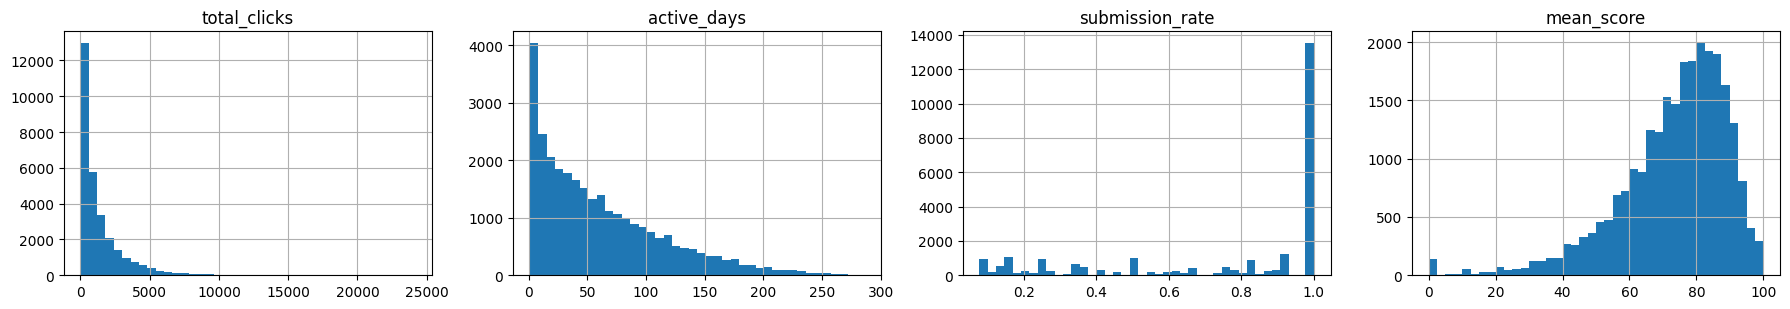

In [5]:
print("=== Missing values per feature ===")
print(df[FEATURES].isna().sum(), "\n")
print("=== submission_rate range ===  min:",
      df["submission_rate"].min(), " max:", df["submission_rate"].max(), "\n")
print("=== Outcome distribution ===")
print(df["final_result"].value_counts(), "\n")

fig, axes = plt.subplots(1, 4, figsize=(18, 3.2))
for ax, col in zip(axes, FEATURES):
    df[col].hist(bins=40, ax=ax); ax.set_title(col)
plt.tight_layout(); plt.show()

## 5. Missing-Value Treatment

Missingness in OULAD is **not random**: students with no VLE records are
predominantly early withdrawals, and students with no assessment scores are those
who submitted nothing. The cross-tabulation below confirms this — missing rates are
far higher among *Withdrawn* students. Dropping these rows would therefore remove
precisely the disengaged learners that RQ4 (completion/withdrawal) is designed to
study, and would erase the most behaviorally distinct cluster.

We therefore treat missing values as **informative zeros**: no VLE activity is encoded
as zero clicks and zero active days; non-submission is encoded as a submission rate of
zero and a demonstrated-attainment score of zero. A student who submitted one
assessment and scored zero remains distinguishable from a non-submitter, because the
two differ on `submission_rate`. (Note: `score` was stored as a string in the raw file
and was coerced to numeric, with non-numeric tokens treated as missing.)

In [6]:
# --- WHO is missing? (empirically justifies the fill strategy) ---
miss = df.assign(no_vle=df["total_clicks"].isna(),
                 no_asmt=df["mean_score"].isna())
print("VLE-missing rate by outcome:")
print(miss.groupby("final_result")["no_vle"].mean().round(3))
print("\nAssessment-missing rate by outcome:")
print(miss.groupby("final_result")["no_asmt"].mean().round(3))

# --- Missing-value strategy: informative zeros ---
FILL_ZERO = True
df_clean = df.copy()
if FILL_ZERO:
    df_clean[FEATURES] = df_clean[FEATURES].fillna(0)
else:
    df_clean = df_clean.dropna(subset=FEATURES)

print("\nRows kept:", df_clean.shape[0], "of", df.shape[0])
print("Remaining NaNs:", df_clean[FEATURES].isna().sum().sum())

VLE-missing rate by outcome:
final_result
Distinction   0.000
Fail          0.053
Pass          0.000
Withdrawn     0.294
Name: no_vle, dtype: float64

Assessment-missing rate by outcome:
final_result
Distinction   0.000
Fail          0.183
Pass          0.000
Withdrawn     0.540
Name: no_asmt, dtype: float64

Rows kept: 32593 of 32593
Remaining NaNs: 0


## 6. Outlier Handling and Standardization

K-medoids represents each cluster by an actual observation (a medoid) rather than a
mean, which makes it inherently robust to extreme values. Aggressive outlier removal
is therefore unnecessary and would risk discarding a legitimate high-engagement
profile. By default we remove **no** students. As an optional robustness control,
the two heavy-tailed engagement features may be winsorized at the 99th percentile —
capping extreme leverage on the distance computation without dropping any case.

All four features are then standardized via **Z-score normalization** (zero mean,
unit variance), so that no single feature dominates the Euclidean dissimilarity
purely because of its scale. We also inspect the inter-feature correlation matrix:
moderate correlation among engagement features is expected and acceptable for
clustering, but it is worth documenting.

In [7]:
# --- Outlier strategy: none by default (K-medoids is robust) ---
WINSORIZE = False
WINSOR_P  = 0.99
dfx = df_clean.copy()
if WINSORIZE:
    for col in ["total_clicks", "active_days"]:
        dfx[col] = dfx[col].clip(upper=dfx[col].quantile(WINSOR_P))

# --- Z-score standardization ---
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(dfx[FEATURES]),
                 columns=FEATURES, index=dfx.index)

print("Standardized summary (mean~0, std~1):")
print(X.describe().T[["mean", "std", "min", "max"]].round(3), "\n")
print("Feature correlations:")
print(dfx[FEATURES].corr().round(2))

Standardized summary (mean~0, std~1):
                  mean   std    min    max
total_clicks    -0.000 1.000 -0.718 13.544
active_days      0.000 1.000 -1.018  4.229
submission_rate -0.000 1.000 -1.419  0.956
mean_score      -0.000 1.000 -1.751  1.277 

Feature correlations:
                 total_clicks  active_days  submission_rate  mean_score
total_clicks            1.000        0.840            0.510       0.440
active_days             0.840        1.000            0.680       0.580
submission_rate         0.510        0.680            1.000       0.760
mean_score              0.440        0.580            0.760       1.000


## 7. RQ1 — Cluster Identification (K-medoids / PAM)

We cluster students using **K-medoids (Partitioning Around Medoids)** on the
Z-standardized behavioral features, with Euclidean dissimilarity. K-medoids is chosen
over K-means because its cluster centers are real observations (medoids), making it
robust to the heavy right-tail of the clickstream features.

**Selecting k.** The number of clusters is chosen by the **Average Silhouette Width
(ASW)**, which measures how well each student fits its assigned cluster relative to the
nearest alternative. ASW is dissimilarity-based and algorithm-agnostic, making it
appropriate here; we deliberately avoid the Elbow method (tied to K-means inertia and
sensitive to outliers) and information criteria such as BIC/AIC (which assume a
probabilistic mixture model and are mismatched to a dissimilarity-based method).

**Scalability.** A full pairwise dissimilarity matrix over all 32,593 students is
computationally prohibitive (~8 GB). We therefore select k on a representative random
sample (n = 8,000), fit the medoids at the chosen k, and then assign **all** students
to their nearest medoid in the standardized feature space. RQ2–RQ4 are subsequently
evaluated on the full dataset, so no student is dropped from the outcome analysis.

k=2:  ASW = 0.4963
k=3:  ASW = 0.4827
k=4:  ASW = 0.4960
k=5:  ASW = 0.4800
k=6:  ASW = 0.4380
k=7:  ASW = 0.4060
k=8:  ASW = 0.3805

>>> Best k by ASW: 2  (ASW = 0.4963)


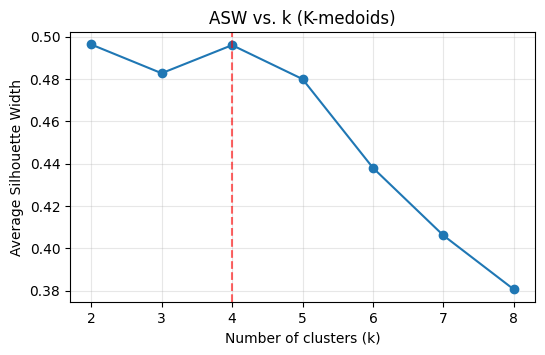

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
# --- Representative sample for k-selection (full matrix over 32k is too large) ---
SAMPLE_N = 8000
K_RANGE  = range(2, 9)

Xs = X.sample(n=SAMPLE_N, random_state=RANDOM_STATE)
D  = pairwise_distances(Xs.values, metric="euclidean")   # n x n dissimilarity

asw_scores = {}
for k in K_RANGE:
    res = kmedoids.fasterpam(D, k, random_state=RANDOM_STATE)
    asw_scores[k] = silhouette_score(Xs.values, res.labels, metric="euclidean")
    print(f"k={k}:  ASW = {asw_scores[k]:.4f}")

best_k = max(asw_scores, key=asw_scores.get)
print(f"\n>>> Best k by ASW: {best_k}  (ASW = {asw_scores[best_k]:.4f})")

SELECTED_K = 4   # makalede gerekçeli olarak k=4 seçildi (ASW k=2 ile pratikte eşit)

plt.figure(figsize=(6, 3.5))
plt.plot(list(asw_scores), list(asw_scores.values()), "o-")
plt.axvline(SELECTED_K, ls="--", c="red", alpha=0.6)   # k=4'ü işaretle
plt.xlabel("Number of clusters (k)"); plt.ylabel("Average Silhouette Width")
plt.title("ASW vs. k (K-medoids)"); plt.grid(alpha=0.3)
plt.savefig("asw_vs_k.png", dpi=300, bbox_inches="tight")   # <-- BURAYA (show'dan ÖNCE)
plt.show()

# --- figürü indir ---
from google.colab import files
files.download("asw_vs_k.png")

## 8. RQ1 — Cluster Assignment and Behavioral Profiles

We fit K-medoids at **k = 4** on the representative sample, obtaining four medoids in
the standardized feature space. Every one of the 32,593 students is then assigned to
its nearest medoid by Euclidean distance, so the full cohort receives a cluster label
without computing a prohibitive 32k × 32k matrix.

**On the choice of k.** ASW was marginally highest at k = 2 (0.4963), but k = 4
(0.4960) was statistically indistinguishable (Δ ≈ 0.0003) while offering substantially
richer structure. A two-cluster solution collapses to a single engaged/disengaged
dichotomy, which is too coarse to support RQ3 (graded engagement) and RQ4 (separating
withdrawal from failure). We therefore selected k = 4: it preserves the silhouette
quality of the global optimum while providing the profile resolution the research
questions require.

Each cluster is then characterized by the mean of its (raw, un-standardized) features,
which is what makes the profiles interpretable as learner types.

Cluster sizes:
cluster
0     7302
1    11802
2     6779
3     6710
Name: count, dtype: int64 

Cluster behavioral profiles (raw feature means):
         total_clicks  active_days  submission_rate  mean_score      n
cluster                                                               
0              61.260        3.830            0.010       1.150   7302
1             937.880       56.320            0.930      74.050  11802
2             456.020       24.500            0.290      67.710   6779
3           3,725.420      141.500            0.970      80.980   6710


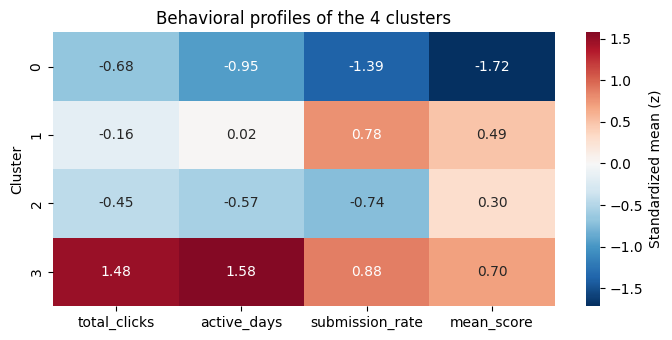

In [9]:
FINAL_K = 4

# --- Fit medoids on the sample, at the chosen k ---
res_final   = kmedoids.fasterpam(D, FINAL_K, random_state=RANDOM_STATE)
medoid_rows = Xs.iloc[res_final.medoids]          # medoid coordinates (standardized)

# --- Assign ALL students to nearest medoid ---
dist_to_medoids = pairwise_distances(X.values, medoid_rows.values, metric="euclidean")
df_clean["cluster"] = dist_to_medoids.argmin(axis=1)

print("Cluster sizes:")
print(df_clean["cluster"].value_counts().sort_index(), "\n")

# --- Behavioral profile = mean of RAW features per cluster (interpretable) ---
profile = (df_clean.groupby("cluster")[FEATURES]
           .mean().round(2)
           .assign(n=df_clean["cluster"].value_counts().sort_index()))
print("Cluster behavioral profiles (raw feature means):")
print(profile)

# --- Heatmap of standardized profiles (for the paper figure) ---
prof_z = X.groupby(df_clean["cluster"]).mean()
plt.figure(figsize=(7, 3.5))
sns.heatmap(prof_z, annot=True, cmap="RdBu_r", center=0, fmt=".2f",
            cbar_kws={"label": "Standardized mean (z)"})
plt.title(f"Behavioral profiles of the {FINAL_K} clusters")
plt.ylabel("Cluster"); plt.tight_layout(); plt.show()

## 9. RQ1 — Interpreted Learner Profiles

The four clusters correspond to substantively distinct and educationally meaningful
learner types, structured along two axes that the correlation analysis anticipated —
behavioral engagement and assessment attainment:

| Cluster | Label | n | Profile |
|---|---|---|---|
| 0 | **Disengaged non-starters** | 7,302 | Minimal clicks/active days, near-zero submission, negligible scores. Predominantly withdrawals and no-shows. |
| 1 | **Consistent completers** | 11,802 | Below-average browsing but high submission rate and solid scores — efficient, task-focused students (largest group). |
| 2 | **Struggling partial participants** | 6,779 | Low engagement and low submission, yet moderate scores when they do submit — a follow-through gap rather than an ability gap. |
| 3 | **Highly engaged achievers** | 6,710 | Top decile on every feature — intensive activity paired with high attainment. |

Notably, Clusters 1 and 3 dissociate engagement from achievement: high attainment is
reached both through intensive activity (Cluster 3) and through lean, targeted
participation (Cluster 1). This dissociation is the kind of structure a single-outcome
evaluation would obscure, and it motivates the multi-outcome tests that follow.

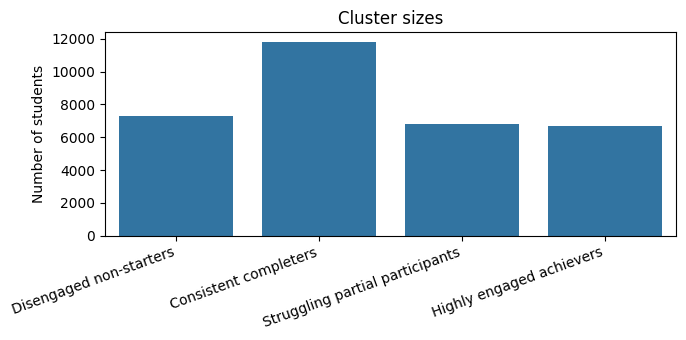

                                 total_clicks  active_days  submission_rate  \
cluster_label                                                                 
Consistent completers                 937.880       56.320            0.930   
Disengaged non-starters                61.260        3.830            0.010   
Highly engaged achievers            3,725.420      141.500            0.970   
Struggling partial participants       456.020       24.500            0.290   

                                 mean_score  
cluster_label                                
Consistent completers                74.050  
Disengaged non-starters               1.150  
Highly engaged achievers             80.980  
Struggling partial participants      67.710  


In [10]:
CLUSTER_LABELS = {
    0: "Disengaged non-starters",
    1: "Consistent completers",
    2: "Struggling partial participants",
    3: "Highly engaged achievers",
}
df_clean["cluster_label"] = df_clean["cluster"].map(CLUSTER_LABELS)

order = [0, 1, 2, 3]
sizes = df_clean["cluster"].value_counts().reindex(order)
plt.figure(figsize=(7, 3.5))
sns.barplot(x=[CLUSTER_LABELS[i] for i in order], y=sizes.values)
plt.ylabel("Number of students"); plt.xticks(rotation=20, ha="right")
plt.title("Cluster sizes"); plt.tight_layout(); plt.show()

print(df_clean.groupby("cluster_label")[FEATURES].mean().round(2))

## 10. RQ2–RQ4 — Outcome Differences Across Profiles

Each research question is tested with a method matched to the outcome's measurement
level. For the two continuous outcomes (RQ2, RQ3) we use the **Kruskal–Wallis H test**,
a non-parametric alternative to one-way ANOVA that does not assume normality —
appropriate given the heavy right-skew of the engagement features. Where the omnibus
test is significant, we follow up with **Dunn's post-hoc test (Bonferroni-corrected)**
to locate which specific cluster pairs differ. For the categorical outcome (RQ4) we use
the **chi-square test of independence**.

**A note on interpretation.** `mean_score` (RQ2) and the engagement features (RQ3) were
themselves inputs to the clustering, so significant differences on these outcomes are
expected and serve to *characterize and confirm* the profile structure rather than to
validate it independently. The genuinely **external** validation is **RQ4**: course
outcome (`final_result`) was never used in clustering, so an association there tests
whether purely behavioral profiles carry information about completion and withdrawal.
Effect sizes are reported alongside p-values, since with n ≈ 32,600 even trivial
differences reach significance; the effect size indicates whether a difference is
also *practically* meaningful.

In [11]:
from scipy.stats import kruskal, chi2_contingency

groups = [g[FEATURES + ["final_result"]] for _, g in df_clean.groupby("cluster")]

def epsilon_sq(H, n, k):
    """Effect size for Kruskal-Wallis: epsilon-squared (0-1)."""
    return (H - k + 1) / (n - k)

n, k = len(df_clean), FINAL_K

# ---------- RQ2: Academic success (mean_score) ----------
print("="*60, "\nRQ2 — Academic success (mean_score)")
H, p = kruskal(*[g["mean_score"] for g in groups])
print(f"Kruskal-Wallis: H={H:.1f}, p={p:.3e}, epsilon^2={epsilon_sq(H,n,k):.3f}")

# ---------- RQ3: Engagement (total_clicks, active_days) ----------
print("="*60, "\nRQ3 — Engagement")
for col in ["total_clicks", "active_days"]:
    H, p = kruskal(*[g[col] for g in groups])
    print(f"  {col:14s}: H={H:.1f}, p={p:.3e}, epsilon^2={epsilon_sq(H,n,k):.3f}")

# ---------- RQ4: Completion / withdrawal (final_result) ----------
print("="*60, "\nRQ4 — Completion / withdrawal (EXTERNAL validation)")
ct = pd.crosstab(df_clean["cluster_label"], df_clean["final_result"])
chi2, p, dof, _ = chi2_contingency(ct)
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"Chi-square: chi2={chi2:.1f}, dof={dof}, p={p:.3e}, Cramer's V={cramers_v:.3f}")
print("\nContingency table (counts):"); print(ct)
print("\nRow-normalized (% within cluster):")
print((ct.div(ct.sum(axis=1), axis=0) * 100).round(1))

RQ2 — Academic success (mean_score)
Kruskal-Wallis: H=18931.2, p=0.000e+00, epsilon^2=0.581
RQ3 — Engagement
  total_clicks  : H=25121.1, p=0.000e+00, epsilon^2=0.771
  active_days   : H=26603.8, p=0.000e+00, epsilon^2=0.816
RQ4 — Completion / withdrawal (EXTERNAL validation)
Chi-square: chi2=25277.5, dof=9, p=0.000e+00, Cramer's V=0.508

Contingency table (counts):
final_result                     Distinction  Fail  Pass  Withdrawn
cluster_label                                                      
Consistent completers                   1363  2087  7691        661
Disengaged non-starters                    0  1455     7       5840
Highly engaged achievers                1642   432  4507        129
Struggling partial participants           19  3078   156       3526

Row-normalized (% within cluster):
final_result                     Distinction   Fail   Pass  Withdrawn
cluster_label                                                        
Consistent completers                 11.500 17

## 11. Post-hoc Pairwise Comparisons (Dunn, Bonferroni)

The Kruskal–Wallis tests establish that the four profiles differ overall, but not which
pairs drive the difference. We therefore run **Dunn's post-hoc test with Bonferroni
correction** on each continuous outcome. With four clusters there are six pairwise
comparisons per outcome; the Bonferroni adjustment controls the family-wise error rate
across them. The resulting matrices report adjusted p-values for every cluster pair.

In [12]:
for col in ["mean_score", "total_clicks", "active_days"]:
    print("="*60, f"\nDunn post-hoc (Bonferroni) — {col}")
    pvals = sp.posthoc_dunn(df_clean, val_col=col, group_col="cluster_label",
                            p_adjust="bonferroni")
    print(pvals.round(4))

Dunn post-hoc (Bonferroni) — mean_score
                                 Consistent completers  \
Consistent completers                            1.000   
Disengaged non-starters                          0.000   
Highly engaged achievers                         0.000   
Struggling partial participants                  0.000   

                                 Disengaged non-starters  \
Consistent completers                              0.000   
Disengaged non-starters                            1.000   
Highly engaged achievers                           0.000   
Struggling partial participants                    0.000   

                                 Highly engaged achievers  \
Consistent completers                               0.000   
Disengaged non-starters                             0.000   
Highly engaged achievers                            1.000   
Struggling partial participants                     0.000   

                                 Struggling partial participan

## 12. Results Figures

Two figures summarize the findings. The first shows each profile's outcome composition
(RQ4) — the study's central, externally-validated result. The second is the behavioral
fingerprint of each profile (RQ1). Significance is omitted from the bars because all
pairwise comparisons are significant at p < .001; with n ≈ 32,600 the substantive
story is carried by effect sizes and the *shape* of the differences, not by p-values.

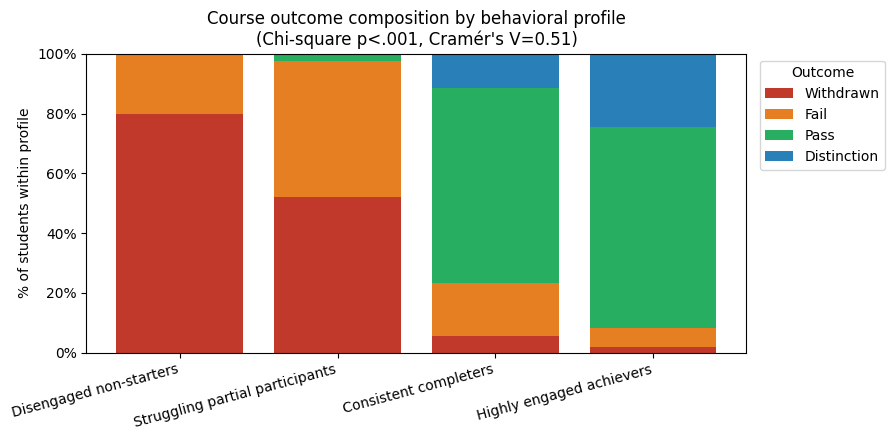

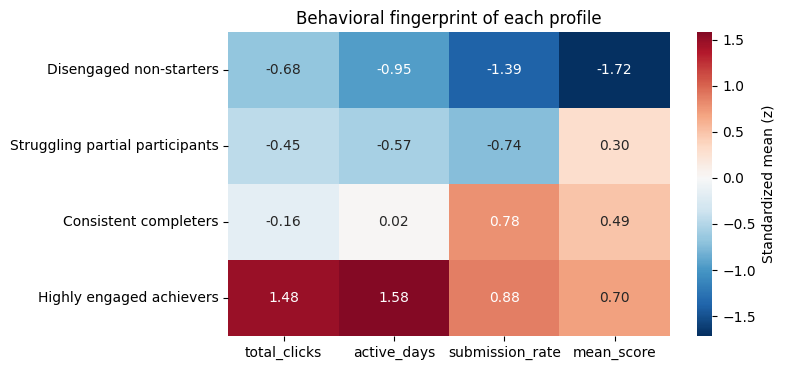

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
import matplotlib.ticker as mtick

order = ["Disengaged non-starters", "Struggling partial participants",
         "Consistent completers", "Highly engaged achievers"]
outcome_order = ["Withdrawn", "Fail", "Pass", "Distinction"]
colors = {"Withdrawn":"#c0392b","Fail":"#e67e22","Pass":"#27ae60","Distinction":"#2980b9"}

# --- Figure 1: outcome composition per profile (RQ4) ---
ct_pct = (pd.crosstab(df_clean["cluster_label"], df_clean["final_result"],
                      normalize="index")*100).reindex(order)[outcome_order]
fig, ax = plt.subplots(figsize=(9, 4.5))
bottom = np.zeros(len(order))
for oc in outcome_order:
    ax.bar(order, ct_pct[oc], bottom=bottom, label=oc, color=colors[oc])
    bottom += ct_pct[oc].values
ax.set_ylabel("% of students within profile"); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_title("Course outcome composition by behavioral profile\n(Chi-square p<.001, Cramér's V=0.51)")
ax.legend(title="Outcome", bbox_to_anchor=(1.01,1)); plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("fig1_outcome_composition.png", dpi=300, bbox_inches="tight")   # <-- EKLE
plt.show()

# --- Figure 2: standardized behavioral fingerprint (RQ1) ---
prof_z = X.groupby(df_clean["cluster"]).mean()
prof_z.index = [CLUSTER_LABELS[i] for i in prof_z.index]
plt.figure(figsize=(8, 3.8))
sns.heatmap(prof_z.reindex(order), annot=True, cmap="RdBu_r", center=0, fmt=".2f",
            cbar_kws={"label":"Standardized mean (z)"})
plt.title("Behavioral fingerprint of each profile"); plt.ylabel("")
plt.tight_layout()
plt.savefig("fig2_fingerprint.png", dpi=300, bbox_inches="tight")            # <-- EKLE
plt.show()

# --- indirme ---
from google.colab import files
files.download("fig1_outcome_composition.png")
files.download("fig2_fingerprint.png")